In [ ]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")

# Select useful features
X = df[['Age', 'Billing Amount']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(X_scaled)

# Separate anomalies
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] == 1]

print("Total anomalies:", len(anomalies))
print(anomalies.head())

## -1 value are outliers

Total anomalies: 2775
                  Name  Age  Gender Blood Type Medical Condition  \
7   CHrisTInA MARtinez   20  Female         A+            Cancer   
8      JASmINe aGuIlaR   82    Male        AB+            Asthma   
20       tIMOTHY burNs   67  Female         A-            Asthma   
40     chRiSTOPHer LEe   74  Female         B-      Hypertension   
62       tRAvIs carTeR   18    Male         A+            Cancer   

   Date of Admission            Doctor                     Hospital  \
7         2021-12-28    Suzanne Thomas  Powell Robinson and Valdez,   
8         2020-07-01   Daniel Ferguson                Sons Rich and   
20        2023-06-28      Krista Smith                    Jones LLC   
40        2021-09-15  William Reynolds                    PLC Young   
62        2022-07-06        Megan Hahn     Moss and Ferguson, Baker   

   Insurance Provider  Billing Amount  Room Number Admission Type  \
7               Cigna    45820.462722          277      Emergency   
8   

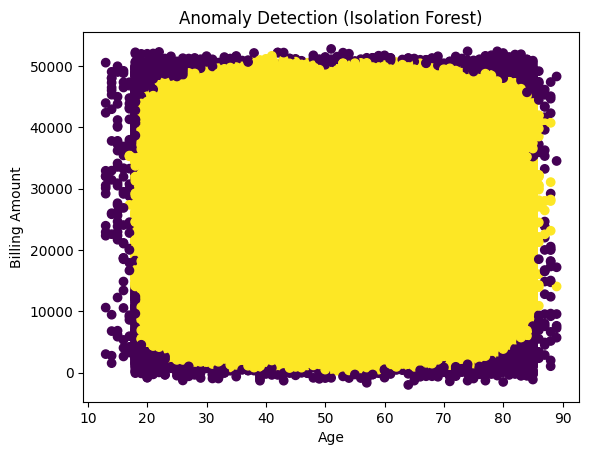

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['Billing Amount'], c=df['anomaly'])
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.title("Anomaly Detection (Isolation Forest)")
plt.show()